# The XOR Problem

Das klassische Einsteigerproblem der neuronalen Netze.
XOR = exklusives ODER: Ausgabe ist 1, wenn die Inputs verschieden sind.

| x1 | x2 | xor |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Schon hier scheitert der simpelste Vorläufer eines Netzes (ein einfaches Neuron ohne Hidden-Layer)
sichtbar und die Lösung zeigt die wichtigste Grundidee, warum neuronale Netze überhaupt stark sind:
**Hidden-Layer + nichtlineare Aktivierung**.


1. Tensoren &rarr; 2. XOR-Daten &rarr; 3. Loss &rarr; 4. Autograd &rarr; 5. Lineares Modell (scheitert) &rarr; 6. Warum Hidden-Layer? &rarr; 7. MLP bauen &rarr; 8. Klassischer Trainings-Loop &rarr; 9. Auswertung &rarr; 10. Ausblick

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

torch.manual_seed(42)

## Lektion 1: Tensoren

Alles in PyTorch ist ein **Tensor** eine mehrdimensionale Zahlenliste mit Typ und Shape.
Erstmalig: `x` erzeugen, `float()` macht daraus Dezimalzahlen (für Gradienten nötig), `reshape` formt um.

In [2]:
# Skalar (0-dimensional), einfache Python-Liste
v = torch.tensor([1.0, 2.0, 3.0])
print("Tensor:", v)
print("Shape:", v.shape, "| Dtype:", v.dtype)

# 2D-Tensor: 2 Zeilen, 3 Spalten
m = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("2D-Shape:", m.shape)
print(m)
# Form umbauen: 2x3 -> 3x2
print("Reshaped:", m.reshape(3, 2))

# Rechnen läuft elementweise
a= torch.arange(4.0)
b = torch.ones(4)
print("a: ", a)
print("b: ", b)
print("a + b:", a + b)
print("a * 10:", a * 10)

Tensor: tensor([1., 2., 3.])
Shape: torch.Size([3]) | Dtype: torch.float32
2D-Shape: torch.Size([2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
Reshaped: tensor([[1, 2],
        [3, 4],
        [5, 6]])
a:  tensor([0., 1., 2., 3.])
b:  tensor([1., 1., 1., 1.])
a + b: tensor([1., 2., 3., 4.])
a * 10: tensor([ 0., 10., 20., 30.])


*Feststellung*
bei reshape muss die anzahl der elemente gleich sein.

(2, 3)  → 6 Elemente
(3, 2)  ✅ (3·2 = 6)
(6, )   ✅ (6 = 6)
(2, 1, 3) ✅ (2·1·3 = 6)
(4, 2)  ❌ (8 ≠ 6) → Fehler

## Lektion 2: Das XOR-Problem als Tensoren

Wir setzen die Wahrheitstabelle in Tensoren um. Pro Datenpunkt bekommen wir **2 Merkmale** (x1, x2)
und **1 Zielwert** (0 oder 1). Form: (Anzahl Punkte, Merkmale) und (Anzahl Punkte, 1).

In [3]:
x_train = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
y_train = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

print("Eingaben:", x_train.shape)
print(x_train)
print("Ziele:", y_train.shape)
print(y_train)

Eingaben: torch.Size([4, 2])
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Ziele: torch.Size([4, 1])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


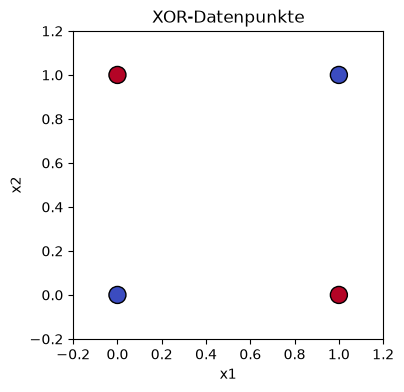

In [4]:
# Visualisierung: Blau = 0, Rot = 1
plt.figure(figsize=(4, 4))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train.flatten().numpy(),
            cmap="coolwarm", s=150, edgecolors="k")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("XOR-Datenpunkte")
plt.show()

In [5]:
# And problem
def plot_truth(points, labels, ax, title):
    ax.scatter(points[:, 0], points[:, 1],
               c=labels.numpy(),
               cmap="coolwarm",
               s=150,
               edgecolors="k")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)


In [6]:
x = torch.tensor([
    [0.0, 0.0],   # AND: 0
    [0.0, 1.0],   # AND: 0
    [1.0, 0.0],   # AND: 0
    [1.0, 1.0],   # AND: 1
])

y_and = torch.tensor([0.0, 0.0, 0.0, 1.0])


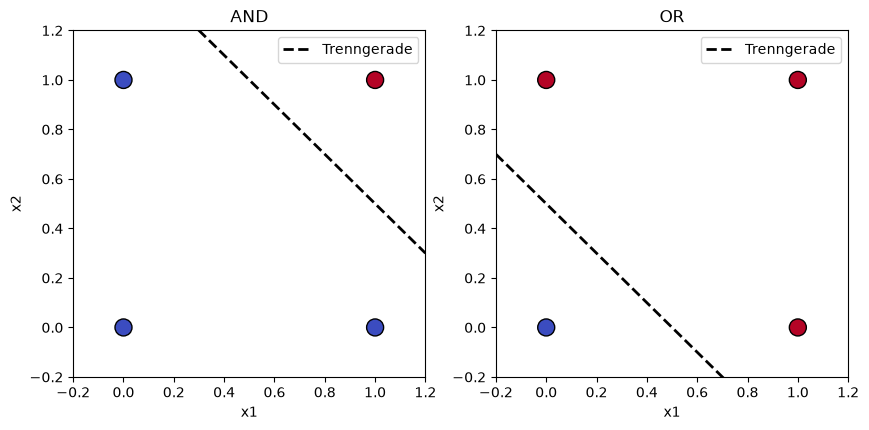

In [7]:
y_or = torch.tensor([0.0, 1.0, 1.0, 1.0])

fig, (ax_and, ax_or) = plt.subplots(1, 2, figsize=(10, 4.5))
plot_truth(x, y_and, ax_and, "AND")
plot_truth(x, y_or, ax_or, "OR")

# Ideale Trenn-Geraden: AND -> x1+x2 = 1.5,  OR -> x1+x2 = 0.5
for ax, c_const in [(ax_and, 1.5), (ax_or, 0.5)]:
    x_line = torch.linspace(-0.2, 1.2, 2)
    y_line = c_const - x_line          # Gerade x1 + x2 = c_const umstellen -> x2 = c_const - x1
    ax.plot(x_line, y_line, "k--", linewidth=2, label="Trenngerade")
    ax.legend()

plt.show()


## Lektion 3: Was ist ein Loss?

Ohne Training tippt das Modell einfach konstant 0.5. Der **Loss** sagt uns, wie weit wir daneben liegen.
Die einfachste Metrik: **MSE** (Mean Squared Error) = Durchschnitt der quadrierten Abweichungen.
Erst händisch gerechnet - das ist übrigens alles, was unter der Haube passiert.

In [8]:
pred_const = torch.full_like(y_train, 0.5)  # naive Schätzung
errors = (pred_const - y_train) ** 2
print("Quadratische Fehler je Punkt:", errors.flatten().tolist())
print("MSE händisch:", errors.mean().item())

# Das gleiche Ergebnis liefert die fertige Loss-Funktion von PyTorch:
mse_fn = nn.MSELoss()
print("MSE via nn.MSELoss:", mse_fn(pred_const, y_train))

Quadratische Fehler je Punkt: [0.25, 0.25, 0.25, 0.25]
MSE händisch: 0.25
MSE via nn.MSELoss: tensor(0.2500)


## Lektion 4: Autograd - das Herzstück von PyTorch

Der Loss muss durch die Modellparameter minimiert werden. Dafür brauchen wir die **Ableitung** des Losses
nach jedem Parameter. PyTorch berechnet die automatisch über das **Computational Graph**:

- Tensoren mit `requires_grad=True` werden gespeichert
- `loss.backward()` füllt `.grad` mit den Ableitungen
- Gradient sagt: "in welche Richtung müssen sich die Parameter bewegen, damit der Loss sinkt"

Ein Mini-Beispiel ohne Netzwerk, um das Prinzip zu sehen: `y = a * x^2 + b`

In [15]:
x = torch.tensor(3.0, requires_grad=True)
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0)

y = a * x**2 + b
print("y = a*x^2 + b =", y.item())

y.backward()  # Ableitungen berechnen

print("dy/dx =", x.grad.item())   # erwartet: 2*a*x = 12
print("dy/da =", a.grad.item())   # erwartet: x^2 = 9
print("b.grad =", b.grad)         # b war nicht requires_grad -> kein Gradient

y = a*x^2 + b = 19.0
dy/dx = 12.0
dy/da = 9.0
b.grad = None


## Lektion 5: Lineares Modell (Perceptron) - und warum es scheitert

Ein `nn.Linear(2, 1)` rechnet `w1*x1 + w2*x2 + b` - eine **Gerade** als Entscheidungsgrenze.
Wir trainieren es mit dem vollen Loop. Spoiler: XOR ist **nicht linear separierbar**, die beste
Gerade kann höchstens 3 von 4 Punkten richtig erwischen (75%). Schau dir die Entscheidungsfläche an.

In [17]:
def plot_decision(model, ax=None):
    """Entscheidungsfläche eines Modells über dem Eingabe-Quadrat."""
    if ax is None:
        ax = plt.gca()
    xs = torch.linspace(-0.2, 1.2, 60)
    xx, yy = torch.meshgrid(xs, xs, indexing="xy")
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        z = model(grid).reshape(xx.shape)
    ax.contourf(xx, yy, z, levels=20, alpha=0.35, cmap="coolwarm")
    ax.scatter(x_train[:, 0], x_train[:, 1], c=y_train.flatten().numpy(),
               cmap="coolwarm", s=100, edgecolors="k")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

Loss: 0.2500
Accuracy: 50%


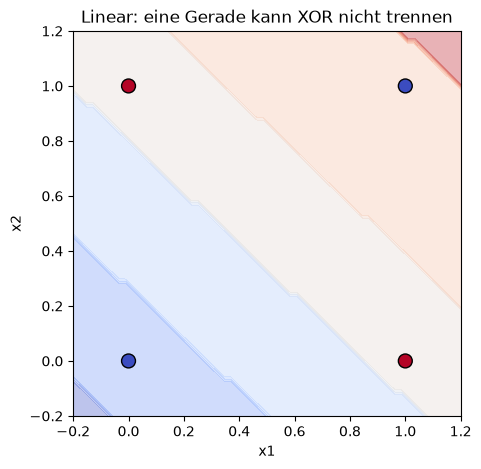

In [11]:
lin = nn.Linear(2, 1)          # 2 Eingaben -> 1 Ausgabe, keine Aktivierung
optimizer = torch.optim.SGD(lin.parameters(), lr=0.2)
loss_fn = nn.MSELoss()

for _ in range(300):
    optimizer.zero_grad()        # alte Gradienten löschen
    pred = lin(x_train)          # Vorhersage (Forward)
    loss = loss_fn(pred, y_train)
    loss.backward()              # Gradienten berechnen
    optimizer.step()             # Parameter der Größe nach anpassen

with torch.no_grad():
    pred_labels = (lin(x_train) > 0.5).int().flatten()
acc = (pred_labels == y_train.flatten()).float().mean().item()
print(f"Loss: {loss.item():.4f}")
print(f"Accuracy: {acc:.0%}")

fig, ax = plt.subplots(figsize=(5, 5))
plot_decision(lin, ax)
ax.set_title("Linear: eine Gerade kann XOR nicht trennen")
plt.show()


Warum ist das so wie es ist ?
    Wir haben hier ein 3 diemensionalen raum in dem wir das problem darstellen (farbcodierung stellen ihre eigene dimension z=1 für rot und z=0 für blau) dar.
    Das ding ist wir können nicht mit einer linearenfunktion die linear ist also in unserem fall z = w1*x1 + w2*x2 (eine Ebene) dieses problem repräsentieren.

Das konzept der Trennung kommt immer bei klassifiern ins spiel durch das festlegen eines Schwellwerts für die eigentliche Entscheidung ist aber nicht das leit tragende problem weshalb lineare neuronen xor nicht darstellen können, sondern ist lediglich die letzte aktivierungsschicht der Ausgabe, das eigentliche problem besteht in der Unfähigkeit das Problem (die Datenpunkte) zu repräsentieren

## Lektion 6: Warum Hidden-Layer + Aktivierung?

Dein Plot oben zeigt das Problem: Das Modell kann nur eine **Gerade** zeichnen.
Farben zu trennen erfordert aber eine **gekrümmte Grenze** (z.B. eine S-Kurve um zwei Punkte).

Ein einzelnes Neuron = lineare Funktion = Gerade. Mehrere Neuronen, deren Ergebnisse durch eine
**nichtlineare Aktivierung** (ReLU, Tanh, Sigmoid) laufen, können zusammen **jede Form** formen.
Das ist die Grundidee der neuronalen Netze: viele einfache Bausteine stapeln und nichtlinear kombinieren.

Deshalb: Hidden Layer &rarr; mehr Ausdruckskraft.

## Lektion 7: Das Mini-Netzwerk (MLP)

Perceptron &rarr; jetzt mit **1 Hidden-Layer** (4 Neuronen, Aktivierung `Tanh`):

`nn.Sequential` stapelt die Schichten. Das Netz rechnet: `Tanh(x1, x2 auf 4 Neuronen) &rarr; 1 Ausgabe`.
Innere Parameter (Gewichte + Bias) legt PyTorch automatisch an - quer durch `.parameters()` sichtbar.

In [12]:
hidden = 4
mlp = nn.Sequential(
    nn.Linear(2, hidden),
    nn.Tanh(),
    nn.Linear(hidden, 1),
)

for name, param in mlp.named_parameters():
    print(name, tuple(param.shape))

n_params = sum(p.numel() for p in mlp.parameters())
print(f"Insgesamt {n_params} trainierbare Parameter (2->4->1)")

print("Vorher (untrainiert):")
print(mlp(x_train).detach().flatten())

0.weight (4, 2)
0.bias (4,)
2.weight (1, 4)
2.bias (1,)
Insgesamt 17 trainierbare Parameter (2->4->1)
Vorher (untrainiert):
tensor([0.2334, 0.0693, 0.3814, 0.1719])


## Lektion 8: Der klassische Trainings-Loop

Das ist das Herzstück jeder PyTorch-Anwendung - eine Schleife mit exakt vier Schritten:

1. `optimizer.zero_grad()` - Gradienten vom vorigen Schritt löschen
2. `pred = model(x)` - Vorhersage (Forward-Pass)
3. `loss = loss_fn(pred, y)` - Fehler berechnen
4. `loss.backward(); optimizer.step()` - Gradienten berechnen und Parameter anpassen

Wir schauen live zu, wie die Entscheidungsfläche entsteht.

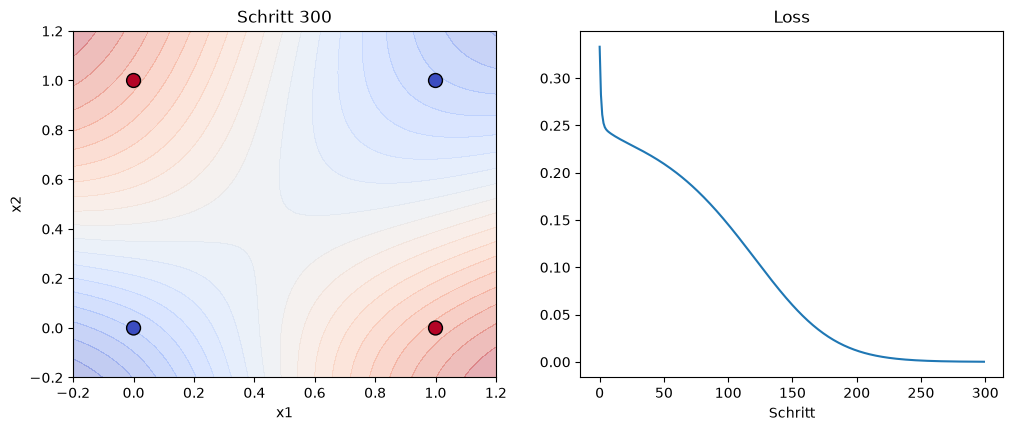

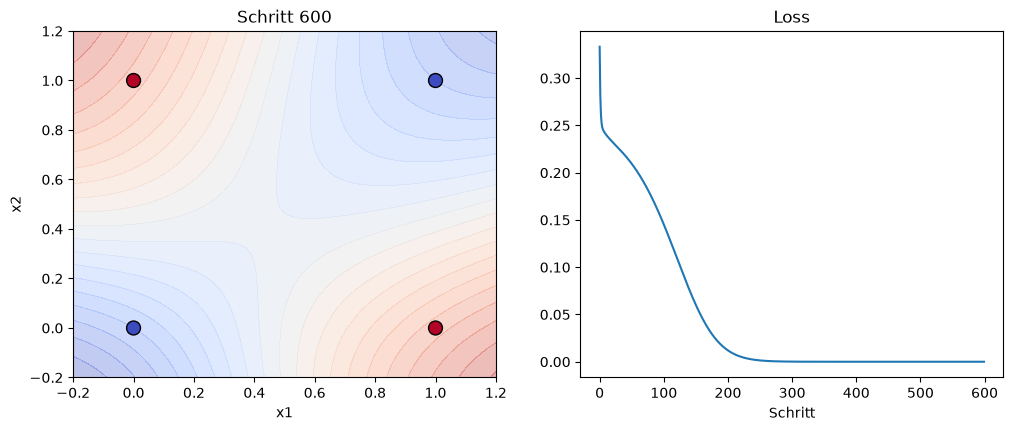

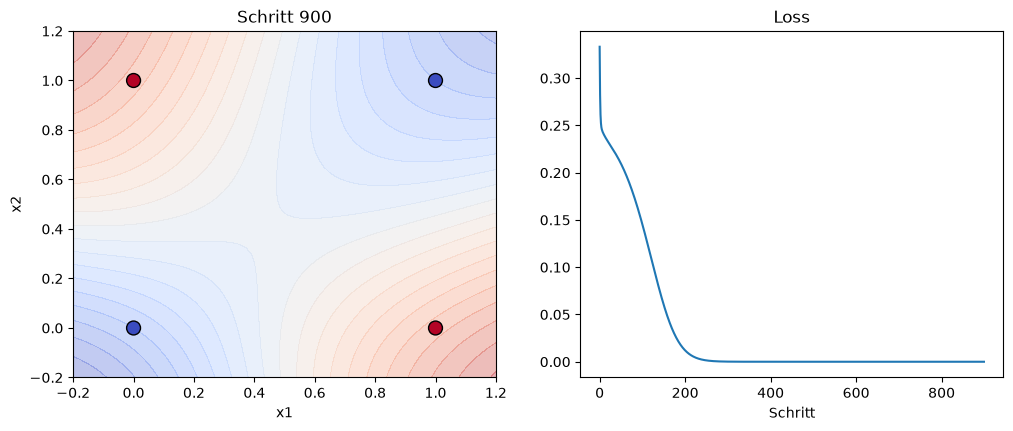

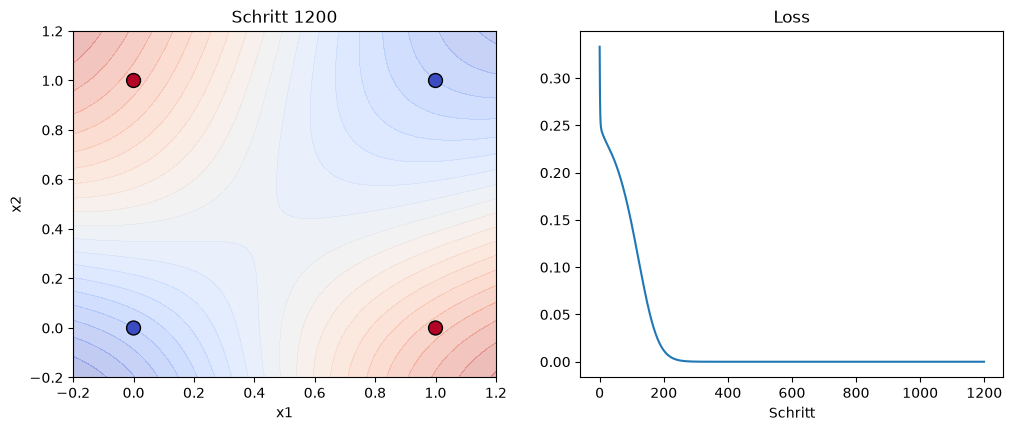

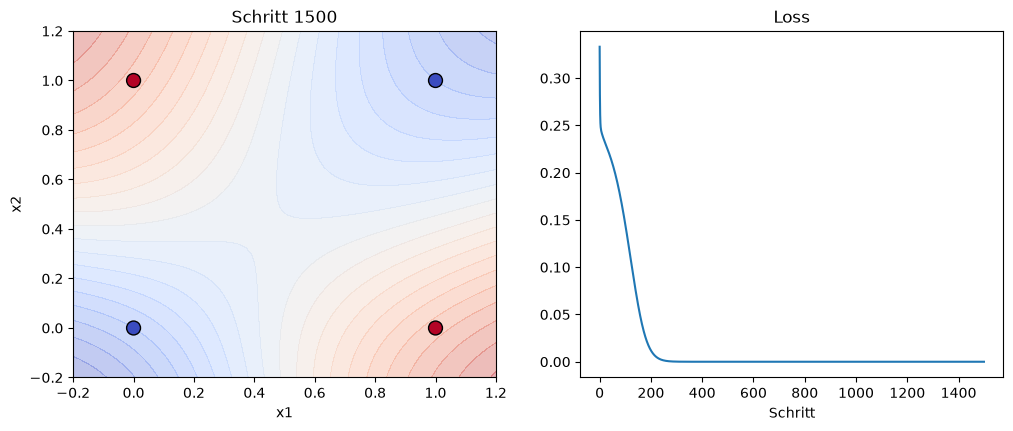

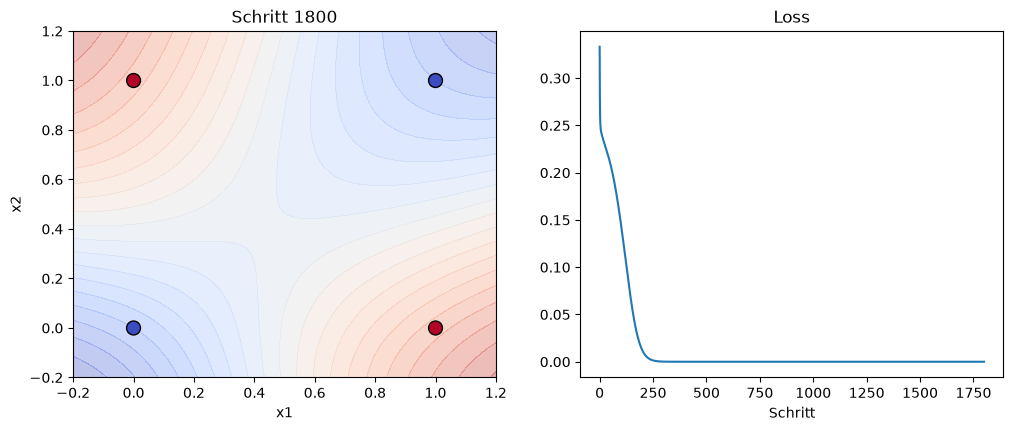

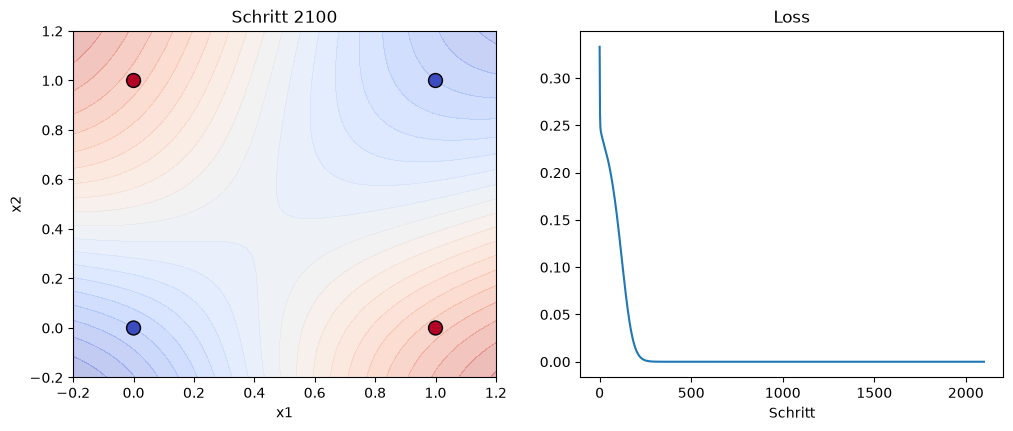

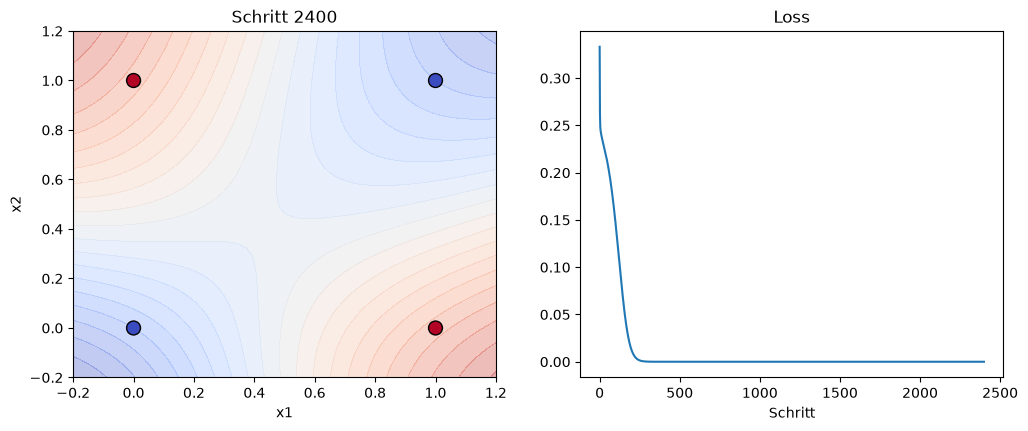

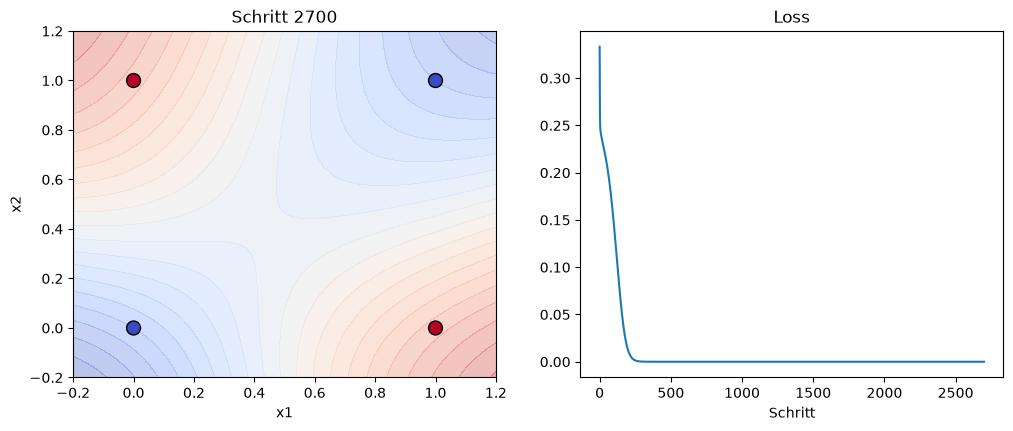

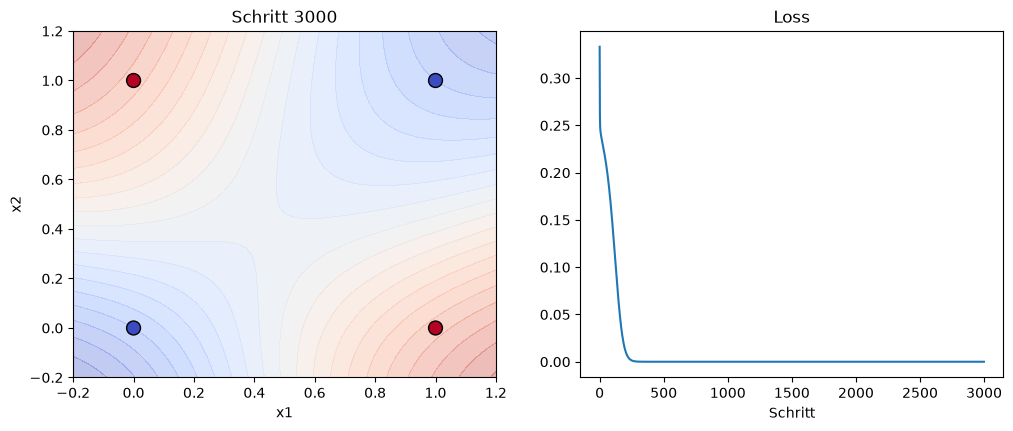

Finaler Loss: 0.000000


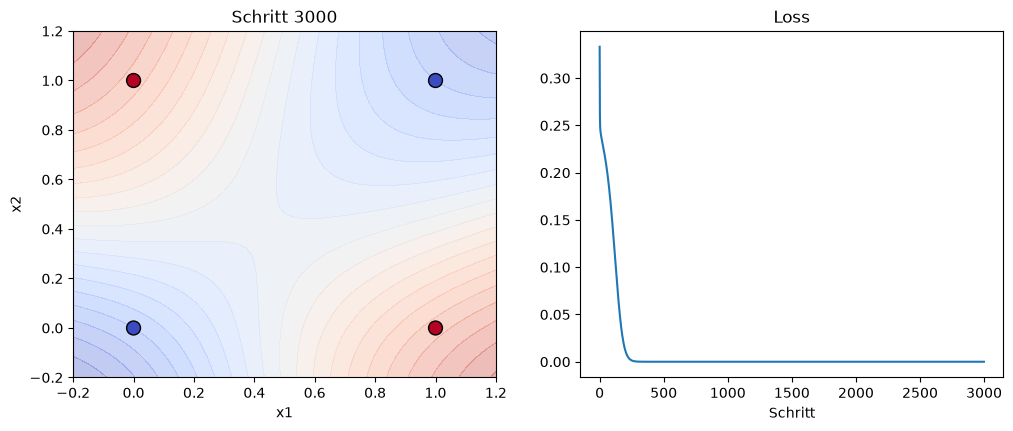

In [13]:
from IPython.display import display, clear_output

optimizer = torch.optim.SGD(mlp.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

epochs = 3000
plot_every = 300
loss_history = []

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.5))

for step in range(1, epochs + 1):
    optimizer.zero_grad()                 # 1. Gradienten löschen
    pred = mlp(x_train)                   # 2. Vorhersage
    loss = loss_fn(pred, y_train)         # 3. Loss
    loss.backward()                       # 4a. Gradienten
    optimizer.step()                      # 4b. Parameter updaten
    loss_history.append(loss.item())

    if step % plot_every == 0 or step == epochs:
        ax_left.clear(); ax_right.clear()
        plot_decision(mlp, ax_left)
        ax_left.set_title(f"Schritt {step}")
        ax_right.plot(loss_history)
        ax_right.set_title("Loss")
        ax_right.set_xlabel("Schritt")
        display(fig)
        clear_output(wait=True)

print(f"Finaler Loss: {loss.item():.6f}")

## Lektion 9: Auswerten

Das Netz gibt pro Punkt einen Wert zwischen 0 und 1 aus. Wir runden auf 0/1 (Schwellwert 0.5)
und vergleichen mit den Zielen. Dann: die Entscheidungsfläche - diesmal sollte sie die Punkte trennen.

Roh-Ausgaben: [7.450580596923828e-07, 0.9999986290931702, 0.9999986290931702, 1.7285346984863281e-06]
Gerundet:     [0, 1, 1, 0]
Wahrheit:     [0, 1, 1, 0]
Accuracy: 100%


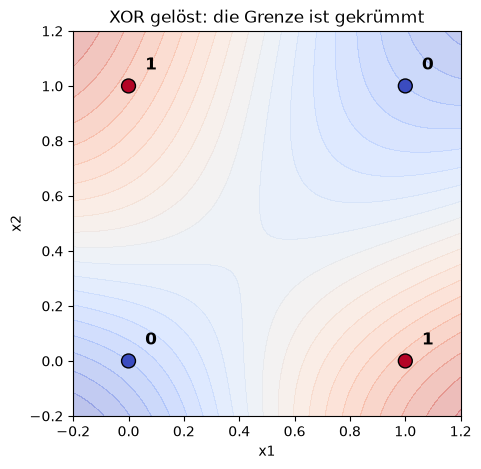

In [14]:
with torch.no_grad():
    prob = mlp(x_train)
    pred_labels = (prob > 0.5).int().flatten()

acc = (pred_labels == y_train.flatten()).float().mean().item()
print("Roh-Ausgaben:", prob.flatten().tolist())
print("Gerundet:    ", pred_labels.tolist())
print("Wahrheit:    ", y_train.flatten().int().tolist())
print(f"Accuracy: {acc:.0%}")

fig, ax = plt.subplots(figsize=(5, 5))
plot_decision(mlp, ax)
for (x0, x1), label in zip(x_train, y_train):
    ax.annotate(str(int(label)), (x0 + 0.06, x1 + 0.06), fontsize=12, fontweight="bold")
ax.set_title("XOR gelöst: die Grenze ist gekrümmt")
plt.show()

## Lektion 10: Ausblick - zum Experimentieren

Schrauben, die du jetzt schon drehen kannst:

- **Lernrate** (`lr=0.01` vs `0.5`) - zu klein = langsam, zu groß = instabil
- **Hidden-Neuronen** (`hidden=2` vs `hidden=8`) - mehr Versuch, langsameres Training
- **Aktivierung** (`nn.ReLU()` statt `nn.Tanh()`) - ReLU ist heute Standard
- **Epochen** - wie lange das Netz übt

Teste es: Einfach eine Zelle oben ändern und neu ausführen. Das hier waren die Foundations.
Was als Nächstes kommt: echte Datensätze, mehr Daten, GPU (`tensor.cuda()`), Overfitting,
Cross-Entropy-Loss für Klassifikation, Konvolutionsnetze, ...